## Zero Shot GeoCIR using GeoCLIP

In [1]:
import sys

sys.path.append("..")
import polars as pl
import os
import torch
from src.utils import read_index
from PIL import Image
import faiss
import json
import matplotlib.pyplot as plt
from src.geoclip import GeoCLIP
from torch import nn
from tqdm import tqdm
from typing import List
import numpy as np
from src.metrics import evaluate
from src.utils import sum_compose

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model_name = "openai/clip-vit-large-patch14"
base_img_path = "../../datasets/google-landmark/index-img"
topk = 100
batch_size = 128

In [11]:
class GeoCLIPCIR(nn.Module):
    def __init__(self, geoclip: GeoCLIP):
        super().__init__()
        self.text_encoder = geoclip.text_encoder
        self.image_encoder = geoclip.image_encoder

    @property
    def device(self):
        return next(self.parameters()).device

    @torch.no_grad()
    def forward(self, text: List[str], images: List[str]):
        img_processed = self.image_encoder.preprocess_image(images)
        text_processed = self.text_encoder.preprocess_text(text)

        img_emb = self.image_encoder(img_processed.to(self.device)).cpu()
        text_emb = self.text_encoder(
            **{k: v.to(self.device) for k, v in text_processed.items()}
        ).cpu()

        return {"img_emb": img_emb, "text_emb": text_emb}


geoclip_model = GeoCLIPCIR(GeoCLIP()).to(device)

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
index, meta = read_index("../index/geoclip_index_gld_siglip_filtered")
index.hnsw.efSearch = 128
meta = meta["metadata"]

In [4]:
test_set = json.loads(open("../../datasets/geocir-triplet/test.v1.json", "r").read())
test_set = test_set["data"]

In [19]:
all_gt = [b["target_img_ids"] for b in test_set]
query_img_ids = [b["ref_img_id"] for b in test_set]
all_pred = []

for i in tqdm(range(0, len(test_set), batch_size), desc="batch test"):
    batch = test_set[i : i + batch_size]
    img_inputs = [os.path.join(base_img_path, f"{b['img_id']}.jpg") for b in batch]
    captions = [b["caption"] for b in batch]

    out = geoclip_model(captions, img_inputs)
    query = sum_compose(**out, alpha=1, beta=2).numpy()

    # retrieve
    sim, ind = index.search(query, topk + 1)
    all_pred.append(ind)

all_pred = np.vstack(all_pred)

evaluate(all_pred, all_gt, query_img_ids)

batch test: 100%|██████████| 128/128 [03:18<00:00,  1.55s/it]


{'mAP@5': 0.015849658135420722,
 'mAP@10': 0.015952284690893676,
 'mAP@25': 0.01715482426099848,
 'mAP@50': 0.01814490062605831,
 'mAP@100': 0.019108943598200045}

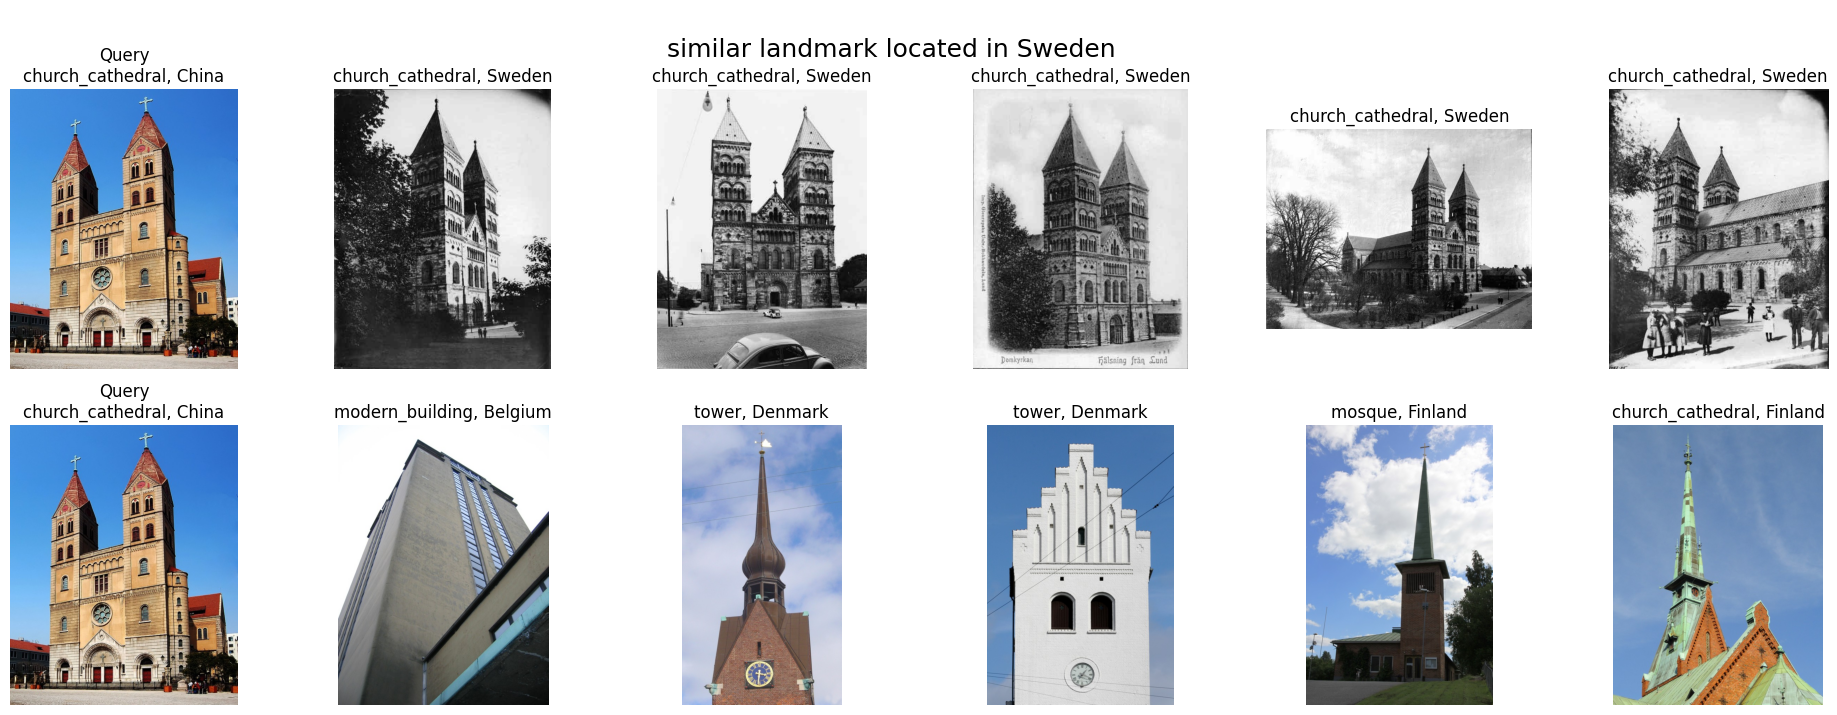

In [17]:
# viz
caption = test_set[12834]["caption"]
query = meta[query_img_ids[12834]]
label = [meta[gt] for gt in all_gt[12834][:5]]
pred = [meta[p] for p in [pred.item() for pred in all_pred[12834] if pred != query_img_ids[12834]][:5]]


fig, ax = plt.subplots(2, 6, figsize=(24, 8))
fig.suptitle(f"\n{caption}\n\n", fontsize=18)
for i in range(2):
    for j in range(6):
        if j == 0 and (i == 0 or i == 1):
            ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{query["id"]}.jpg")))
            ax[i, j].set_title(f"Query\n{query["category"]}, {query["country"]}")
        else:
            if i == 0:
                ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{label[j-1]["id"]}.jpg")))
                ax[i, j].set_title(f"{label[j-1]["category"]}, {label[j-1]["country"]}")
            if i == 1:
                ax[i, j].imshow(Image.open(os.path.join(base_img_path, f"{pred[j-1]["id"]}.jpg")))
                ax[i, j].set_title(f"{pred[j-1]["category"]}, {pred[j-1]["country"]}")
        ax[i, j].axis("off")


# plt.tight_layout()
plt.show()